In [1]:
# Import necessary libraries for data manipulation and analysis
import numpy as np # Numerical operations
import pandas as pd # Data manipulation
from datetime import datetime, timedelta # Date operations

#Import necessary libraries for transformations
from sklearn.preprocessing import MinMaxScaler, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from scipy import stats
from scipy.stats import skew, kurtosis

# Import libraries for plotting and visualization
import matplotlib.pyplot as plt # Matplotlib for basic plotting
import seaborn as sns # Seaborn for enhanced visualization
import plotly.express as px # Plotly for interactive plots

# Import libraries for time series analysis and modeling
from statsmodels.tsa.stattools import adfuller # Augmented Dickey-Fuller Test for stationarity check
from statsmodels.tsa.stattools import kpss # Kwiatkowski-Phillips-Schmidt-Shin Test for stationarity check
from statsmodels.tsa.statespace.sarimax import SARIMAX # SARIMAX model for time series forecasting
from statsmodels.tsa.seasonal import seasonal_decompose # Seasonal decomposition for trend, seasonal, and residual components
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
from pmdarima.arima import auto_arima #SARIMAX using pmdarima

# Import necessary libraries for computing acf and pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf  # For autocorrelation and partial autocorrelation plots
from statsmodels.tsa.stattools import acf, pacf  # For computing autocorrelation and partial autocorrelation

#Import libraries for multicollineaarity
from statsmodels.stats.outliers_influence import variance_inflation_factor

#Import libraries for transformations
import joblib



In [2]:
from SARIMAX import remove_multicollinear, calculate_vif
import datascript
from datascript import load_data, split_data
import os

SARIMAX for MINDANAO
DATA PREPROCESSING

In [3]:
#Import the necessary files
base_path = os.path.dirname(os.path.abspath(datascript.__file__))  # Gets the current working directory
complete_min_gwap = load_data("MIN",'GWAP', features = False, transformed=False)
complete_min_lwap = load_data("MIN",'LWAP', features = False, transformed=False)

In [4]:
GWAP = load_data("MIN",'GWAP', model='SARIMAX', features = False, transformed=True)
LWAP = load_data("MIN",'LWAP', model='SARIMAX', features = False, transformed=True)

GWAP_transformed_features = load_data("MIN",'GWAP', model='SARIMAX', features = True, transformed=True)

In [5]:
%run SARIMAX.py
#Prepare exogenous variables and check for multicollinearity
full_transformed_exog = GWAP_transformed_features.drop(columns=['GWAP'])
full_transformed_exog = full_transformed_exog.shift(1)
full_transformed_exog = full_transformed_exog.fillna(0)
full_exog_train, full_exog_test = split_data(full_transformed_exog, False)

exog_train = remove_multicollinear(full_exog_train, 10)
calculate_vif(exog_train)

final_exog = drop_unmatched_columns(full_transformed_exog, exog_train)

Dropping TMAX_Surigao with VIF of 42.6854766439307
Dropping Demand with VIF of 41.49285559459883
Dropping TMIN_Dipolog with VIF of 38.25284698692718
Dropping TMIN_Butuan with VIF of 34.64722574632823
Dropping TMAX_Malaybalay with VIF of 32.47961157979682
Dropping TMAX_General Santos with VIF of 30.73079070932413
Dropping TMAX_Dipolog with VIF of 26.94661052676652
Dropping TMIN_Davao City with VIF of 26.154237382819385
Dropping TMIN_Zamboanga with VIF of 20.40163695866004
Dropping TMAX_Butuan with VIF of 17.93469720864229
Dropping TMAX_Davao City with VIF of 14.40034948324543
Dropping TMIN_Surigao with VIF of 14.001228957214128
Dropping TMAX_Zamboanga with VIF of 12.858112519637723
Dropping TMIN_General Santos with VIF of 10.496297288838864
Final VIF values:
                     feature       VIF
0                  FLOW_MIN  2.600204
1           Reserve_GWAP_Fr  3.747425
2           Reserve_GWAP_Ru  5.407114
3           Reserve_GWAP_Rd  3.420250
4           Reserve_GWAP_Dr  3.474269
5  

In [6]:
#Prepare the necessary datasets
#Target Variables
GWAP_train, GWAP_test = split_data(GWAP, False)
LWAP_train, LWAP_test = split_data(LWAP, False)

#Untransformed variables for verification 
untransformed_GWAP_train, untransformed_GWAP_test = split_data(complete_min_gwap, False)
untransformed_LWAP_train, untransformed_LWAP_test = split_data(complete_min_lwap, False)



/opt/anaconda3/lib/python3.11/site-packages/_plotly_utils/basevalidators.py:106: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  v = v.dt.to_pydatetime()
/opt/anaconda3/lib/python3.11/site-packages/_plotly_utils/basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



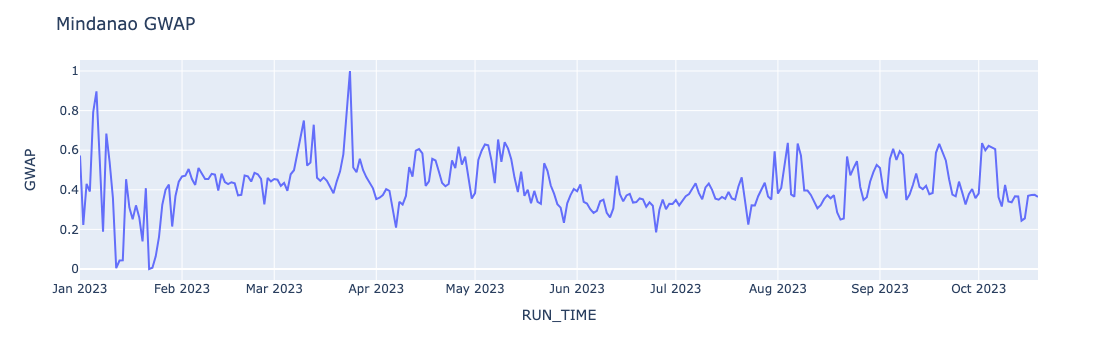

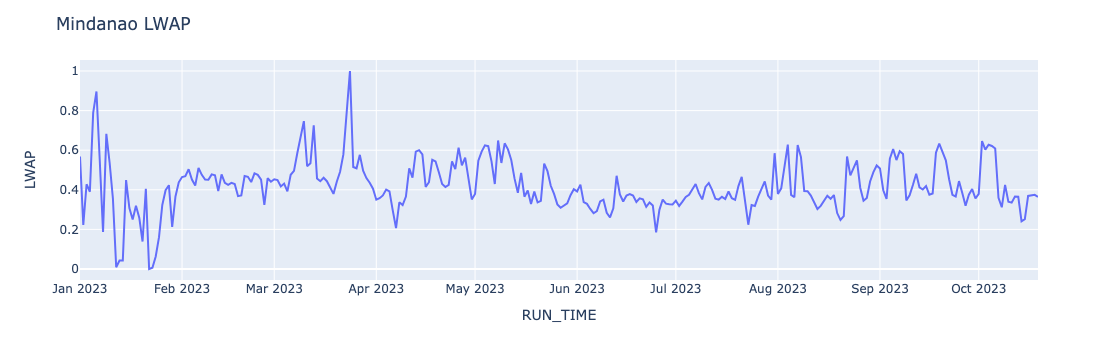

In [7]:
#Plotting Train LWAP ang GWAP
# Create the line plot
gwap_plot = px.line(GWAP_train, x=GWAP_train.index, y='GWAP')
lwap_plot = px.line(LWAP_train, x=LWAP_train.index, y='LWAP')
# Set the title using the ticker value
gwap_plot.update_layout(title=f"Mindanao GWAP")
lwap_plot.update_layout(title=f"Mindanao LWAP")
# Display the plot
gwap_plot.show()
lwap_plot.show()

Differencing

In [8]:
%run SARIMAX.py

#Checking for stationarity in GWAP data
differenced_GWAP = perform_differencing(GWAP_train, GWAP)
differenced_LWAP = perform_differencing(LWAP_train, LWAP)

GWAP_train, GWAP_test = split_data(differenced_GWAP, False)
LWAP_train, LWAP_test = split_data(differenced_LWAP, False)

Data is stationary after differencing 0 times.
Data is stationary after differencing 0 times.


/Users/ac/Desktop/sarimax (03-12)/SARIMAX.py:65: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.


/Users/ac/Desktop/sarimax (03-12)/SARIMAX.py:65: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




In [9]:
#Perform differencing on train exogenous data
diff_full_exog = perform_df_differencing(exog_train, final_exog)
diff_full_exog = diff_full_exog.fillna(0)
exog_train, exog_test = split_data(diff_full_exog, False)

/Users/ac/Desktop/sarimax (03-12)/SARIMAX.py:96: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.


/Users/ac/Desktop/sarimax (03-12)/SARIMAX.py:96: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.


/Users/ac/Desktop/sarimax (03-12)/SARIMAX.py:96: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.


/Users/ac/Desktop/sarimax (03-12)/SARIMAX.py:96: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.


/Users/ac/Desktop/sarimax (03-12)/SARIMAX.py:96: InterpolationWarning:

The test statistic is outside of the range of p-values a

Column 'FLOW_MIN' is stationary after differencing 1 times.
Column 'Reserve_GWAP_Fr' is stationary after differencing 1 times.
Column 'Reserve_GWAP_Ru' is stationary after differencing 1 times.
Column 'Reserve_GWAP_Rd' is stationary after differencing 1 times.
Column 'Reserve_GWAP_Dr' is stationary after differencing 1 times.
Column 'RAINFALL_Davao City' is stationary after differencing 0 times.
Column 'RAINFALL_Surigao' is stationary after differencing 1 times.
Column 'RAINFALL_Zamboanga' is stationary after differencing 1 times.
Column 'RAINFALL_Dipolog' is stationary after differencing 1 times.
Column 'RAINFALL_Butuan' could not be made stationary after 3 differencing operations.
Column 'RAINFALL_Malaybalay' is stationary after differencing 1 times.
Column 'TMIN_Malaybalay' is stationary after differencing 2 times.
Column 'RAINFALL_General Santos' is stationary after differencing 0 times.
Column 'RAINFALL_Cotabato' is stationary after differencing 0 times.
Column 'TMAX_Cotabato' is 

/Users/ac/Desktop/sarimax (03-12)/SARIMAX.py:96: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




Order Specification

The ACF for GWAP is seen below
The PACF for GWAP is seen below


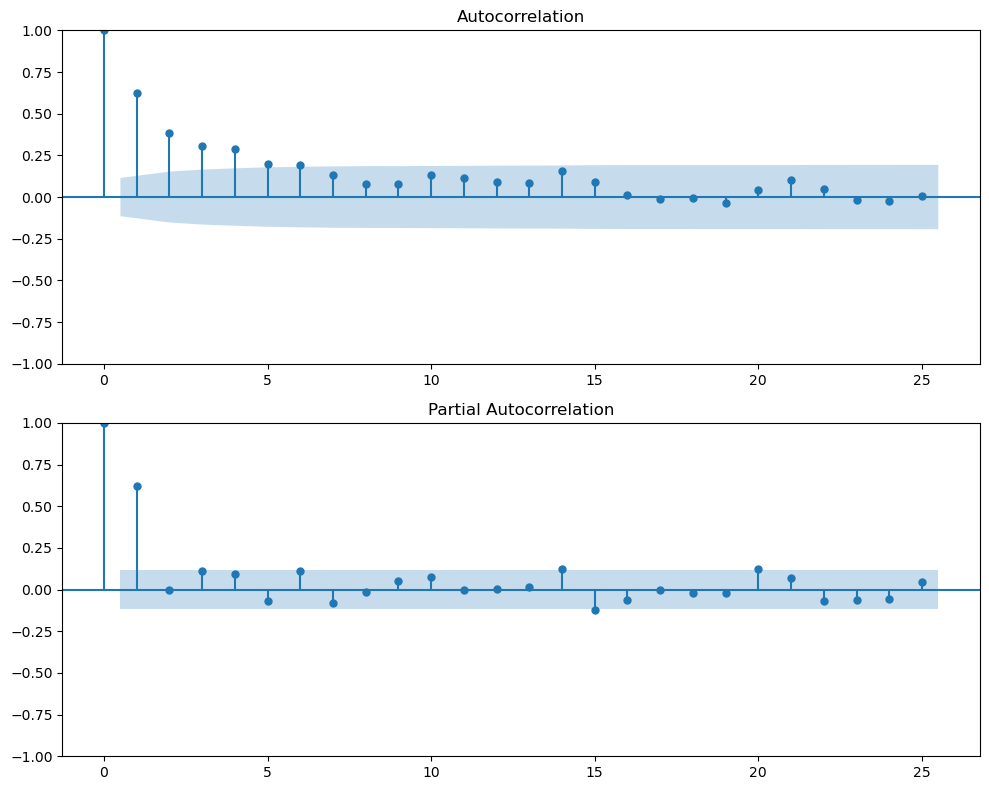

The ACF for LWAP is seen below
The PACF for LWAP is seen below


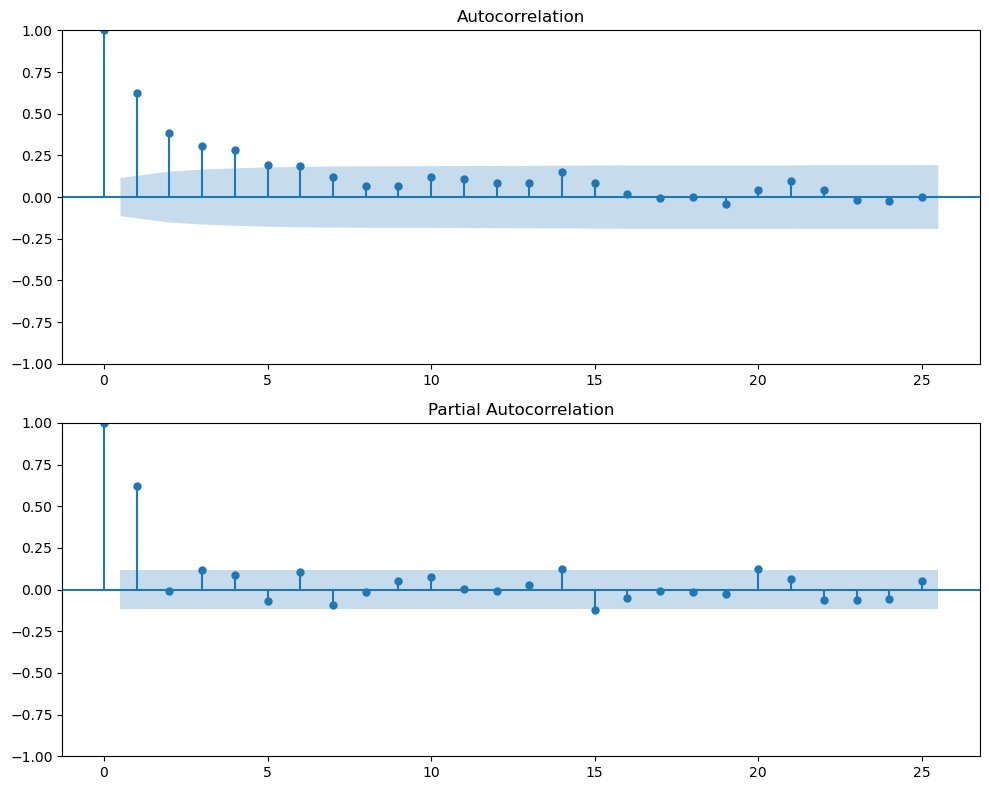

In [10]:
%run SARIMAX.py
plot_orders(GWAP_train, lags=25, alpha=0.05, var='GWAP')
plot_orders(LWAP_train, lags=25, alpha=0.05, var='LWAP')

GWAP and LWAP Forecasting

In [ ]:
%run SARIMAX.py
#Run seasonal_auto_arima function on GWAP 
#Use max_p and max_q based on acf and pacf plots
GWAP_sarimax = seasonal_auto_arima(GWAP_train, max_p=1, max_d=2, max_q=5, exog_data=exog_train )

#Display results of previous function
GWAP_sarimax

In [ ]:
%run SARIMAX.py
#Run seasonal_auto_arima function on GWAP 
#Use max_p and max_q based on acf and pacf plots
LWAP_sarimax = seasonal_auto_arima(LWAP_train, max_p=1, max_d=2, max_q=5, exog_data=exog_train )

#Display results of previous function
LWAP_sarimax

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



Optimization terminated successfully.
         Current function value: -0.949458
         Iterations: 13
         Function evaluations: 2455
                                      SARIMAX Results                                      
Dep. Variable:                                GWAP   No. Observations:                  292
Model:             SARIMAX(1, 0, 0)x(2, 0, [1], 7)   Log Likelihood                 277.242
Date:                             Sat, 15 Mar 2025   AIC                           -512.483
Time:                                     16:39:25   BIC                           -435.272
Sample:                                 01-01-2023   HQIC                          -481.555
                                      - 10-19-2023                                         
Covariance Type:                               opg                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



Optimization terminated successfully.
         Current function value: -0.951401
         Iterations: 13
         Function evaluations: 2443
                                      SARIMAX Results                                      
Dep. Variable:                                LWAP   No. Observations:                  292
Model:             SARIMAX(1, 0, 0)x(2, 0, [1], 7)   Log Likelihood                 277.809
Date:                             Sat, 15 Mar 2025   AIC                           -513.618
Time:                                     16:43:19   BIC                           -436.406
Sample:                                 01-01-2023   HQIC                          -482.690
                                      - 10-19-2023                                         
Covariance Type:                               opg                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------

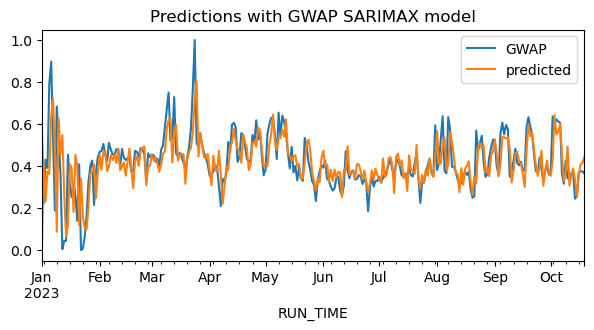

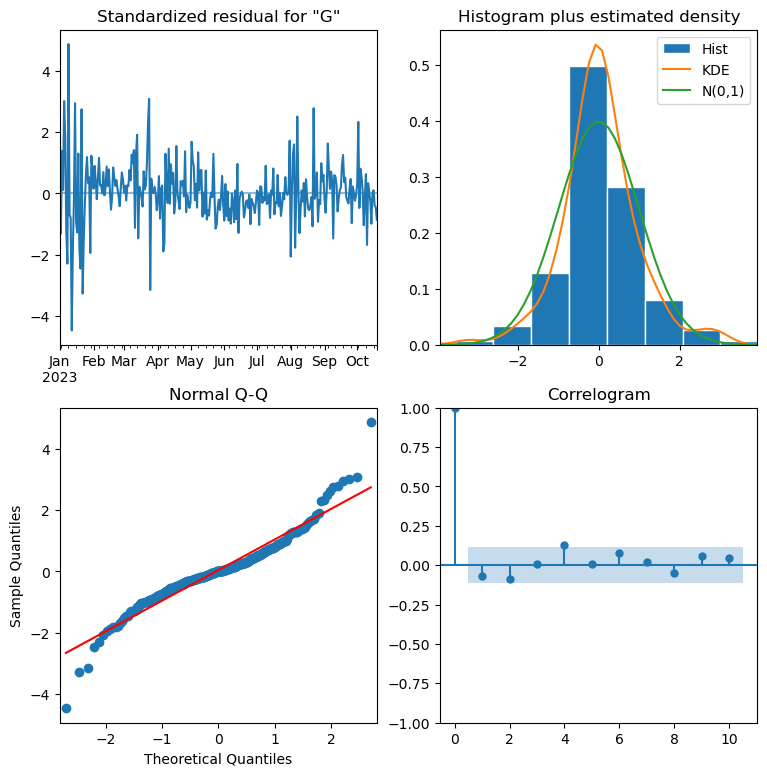

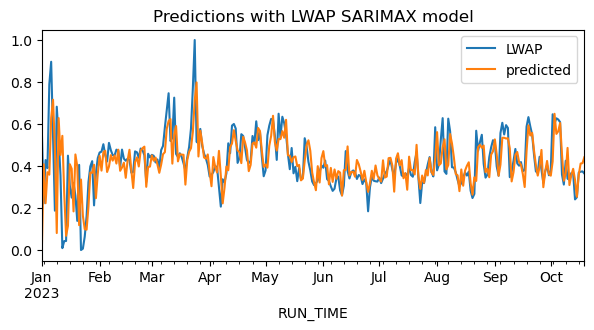

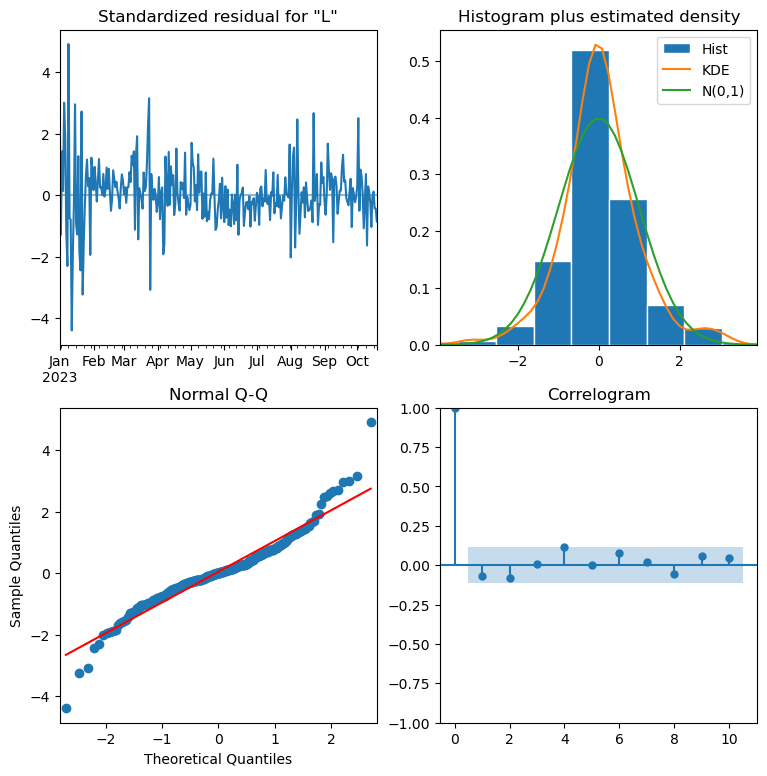

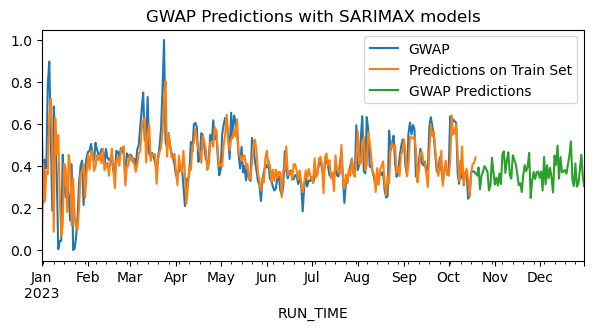

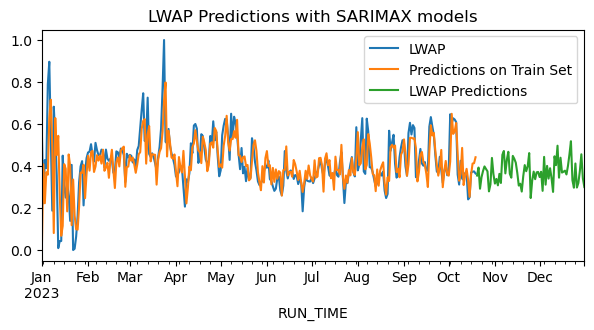

In [11]:
#Optimized orders for GWAP are (1,0,0)(2,0,1,7) and for LWAP are (1,0,0)(2,0,1)(7)
#This function fits the model and plots predictions on the train set; shows the summary of results and residuals diagnostics; and predicts on train set
%run SARIMAX.py

gwap_model_results, lwap_model_results, gwap_test_predict, lwap_test_predict, gwap_train_predict, lwap_train_predict = fit_SARIMAX(gwap_endog=GWAP_train, lwap_endog= LWAP_train, train_exog=exog_train, gwap_order=(1,0,0), gwap_seasonal_order=(2,0,1,7), lwap_order = (1,0,0), lwap_seasonal_order=(2,0,1,7), GWAP_test=GWAP_test, LWAP_test=LWAP_test, exog_test = exog_test)


GWAP Residual Analysis

In [12]:
#Generate residuals for GWAP
%run GARCH.py

gwap_resid_complete, gwap_resid_train = generate_resid(
    'GWAP',
    GWAP_train,
    GWAP_test,
    gwap_train_predict,
    gwap_test_predict,
    gwap_model_results
)

2023-01-01    0.573501
2023-01-02   -0.188654
2023-01-03    0.198618
2023-01-04    0.016842
2023-01-05    0.428944
2023-01-06    0.261233
2023-01-07   -0.171433
2023-01-08   -0.298364
2023-01-09    0.596889
2023-01-10   -0.086705
2023-01-11   -0.096606
2023-01-12   -0.543245
2023-01-13   -0.220403
2023-01-14   -0.021828
2023-01-15    0.334278
2023-01-16   -0.099888
2023-01-17   -0.136974
2023-01-18    0.139628
2023-01-19   -0.192931
2023-01-20   -0.261383
2023-01-21    0.290510
2023-01-22   -0.340300
2023-01-23   -0.153588
2023-01-24   -0.036164
2023-01-25    0.062979
2023-01-26    0.120521
2023-01-27    0.033842
2023-01-28    0.052782
2023-01-29   -0.193954
2023-01-30    0.121048
2023-01-31    0.075451
2023-02-01    0.015239
2023-02-02    0.088407
2023-02-03    0.038932
2023-02-04   -0.018354
2023-02-05    0.048485
2023-02-06    0.111914
2023-02-07    0.025376
2023-02-08    0.026612
2023-02-09    0.000195
2023-02-10    0.067022
2023-02-11   -0.005860
2023-02-12    0.017070
2023-02-13 

RUN_TIME
2023-01-01    0.573501
2023-01-02   -0.188654
2023-01-03    0.198618
2023-01-04    0.016842
2023-01-05    0.428944
2023-01-06    0.261233
2023-01-07   -0.171433
2023-01-08   -0.298364
2023-01-09    0.596889
2023-01-10   -0.086705
2023-01-11   -0.096606
2023-01-12   -0.543245
2023-01-13   -0.220403
2023-01-14   -0.021828
2023-01-15    0.334278
2023-01-16   -0.099888
2023-01-17   -0.136974
2023-01-18    0.139628
2023-01-19   -0.192931
2023-01-20   -0.261383
2023-01-21    0.290510
2023-01-22   -0.340300
2023-01-23   -0.153588
2023-01-24   -0.036164
2023-01-25    0.062979
2023-01-26    0.120521
2023-01-27    0.033842
2023-01-28    0.052782
2023-01-29   -0.193954
2023-01-30    0.121048
2023-01-31    0.075451
2023-02-01    0.015239
2023-02-02    0.088407
2023-02-03    0.038932
2023-02-04   -0.018354
2023-02-05    0.048485
2023-02-06    0.111914
2023-02-07    0.025376
2023-02-08    0.026612
2023-02-09    0.000195
2023-02-10    0.067022
2023-02-11   -0.005860
2023-02-12    0.017070
20

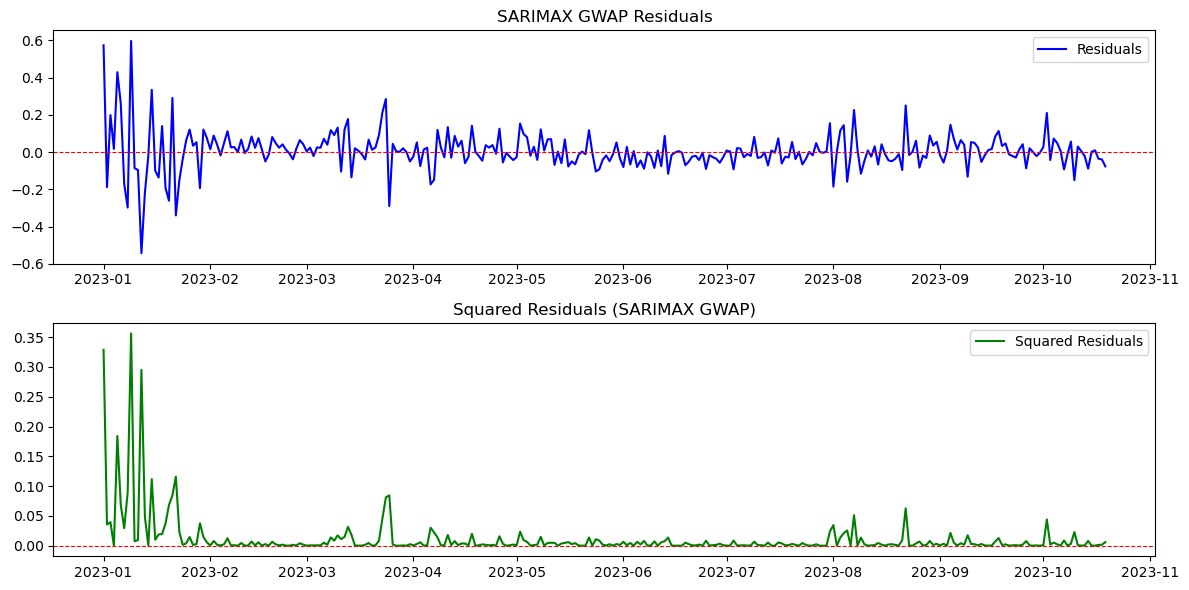

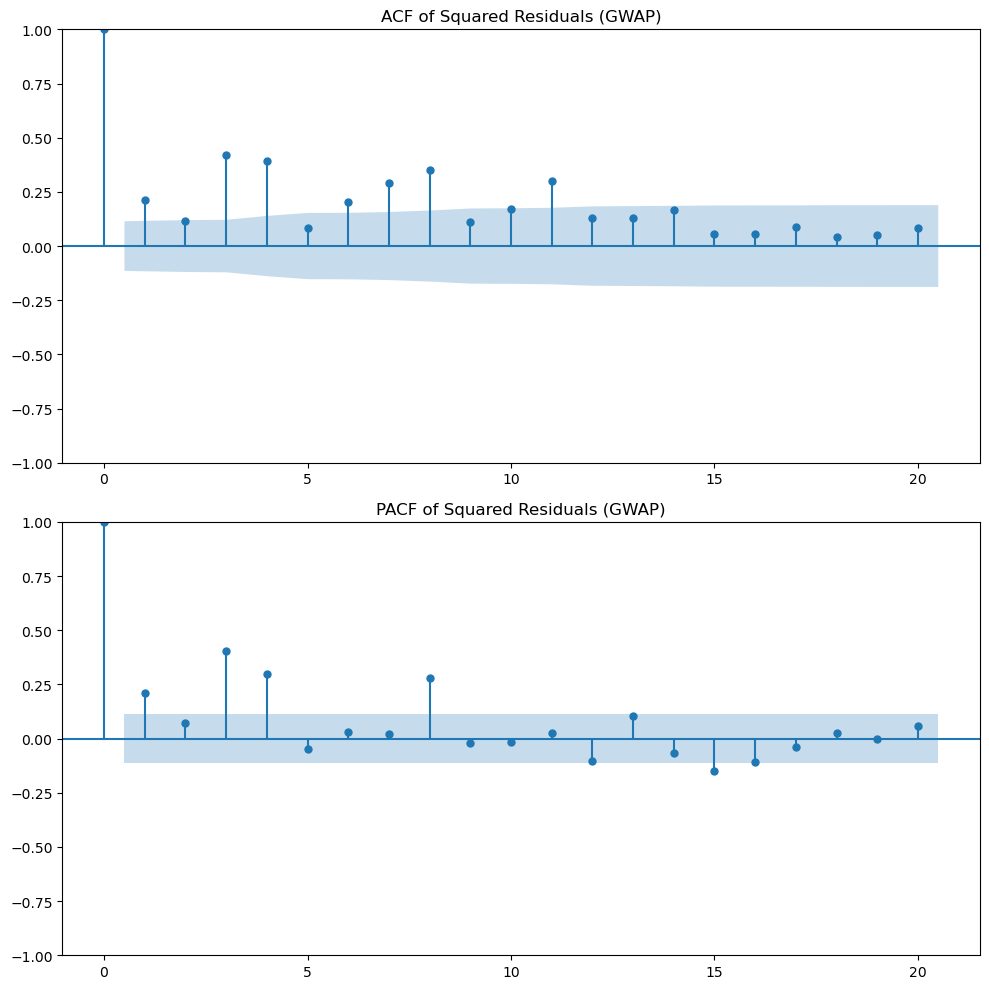

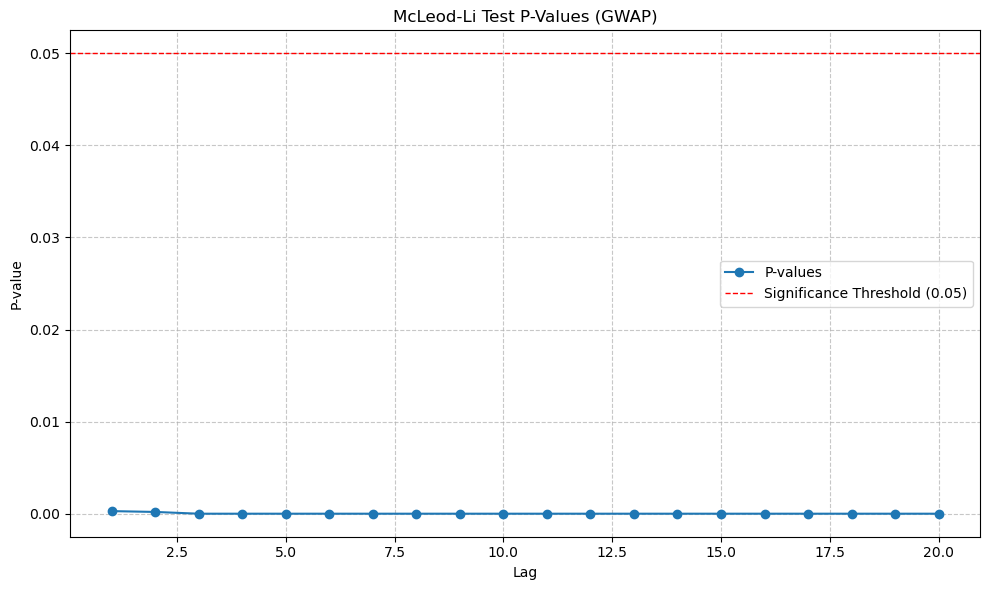

,Lag,PQ Test Stat,PQ p-value,LM Test Stat,LM p-value
0,1,13.187431,2.818330e-04,17.199935,3.364479e-05
1,2,17.125144,1.911271e-04,20.325270,3.858546e-05
2,3,69.594541,5.212862e-15,78.745622,5.702594e-17
3,4,115.422945,5.069311e-24,124.308025,6.415881e-26
4,5,117.540274,1.041332e-23,116.171480,2.029167e-23
5,6,130.162138,1.188159e-25,114.915684,1.901774e-22
6,7,155.464384,2.885855e-30,115.251604,7.452743e-22
7,8,192.423041,2.517725e-37,152.159406,6.948561e-29
8,9,196.039756,2.239174e-37,151.204108,4.965584e-28
9,10,205.082893,1.403807e-38,164.122939,4.559608e-30


In [13]:
#Conducting residual analysis
%run GARCH.py

garch_testing(gwap_resid_train, 'GWAP', max_lag=20)

GWAP GARCH

In [14]:
#Choosing order specification based on lowest AIC/BIC
%run GARCH.py

evaluate_garch(
    gwap_resid_train, 
    vol="GARCH", 
    p_orders=[0,1,3,4,8], 
    q_orders=[0,1,3,4,6,7,8,11], 
    distributions=["normal", "t", "ged"], 
    sort_by="AIC"
)

Error for GARCH(0,1) with normal distribution: One of p or o must be strictly positive
Error for GARCH(0,1) with t distribution: One of p or o must be strictly positive
Error for GARCH(0,1) with ged distribution: One of p or o must be strictly positive
Error for GARCH(0,3) with normal distribution: One of p or o must be strictly positive
Error for GARCH(0,3) with t distribution: One of p or o must be strictly positive
Error for GARCH(0,3) with ged distribution: One of p or o must be strictly positive
Error for GARCH(0,4) with normal distribution: One of p or o must be strictly positive
Error for GARCH(0,4) with t distribution: One of p or o must be strictly positive
Error for GARCH(0,4) with ged distribution: One of p or o must be strictly positive
Error for GARCH(0,6) with normal distribution: One of p or o must be strictly positive
Error for GARCH(0,6) with t distribution: One of p or o must be strictly positive
Error for GARCH(0,6) with ged distribution: One of p or o must be strict

/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.01167. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.01167. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled

,p,q,Volatility Model,Distribution,AIC,BIC,LLF,ARCH Stat,ARCH p-value,alpha_1,alpha_pval_1,beta_1,beta_pval_1,beta_2,beta_3,beta_pval_2,beta_pval_3,beta_4,beta_pval_4,beta_5,beta_6,beta_pval_5,beta_pval_6,beta_7,beta_pval_7,beta_8,beta_pval_8,beta_9,beta_10,beta_11,beta_pval_9,beta_pval_10,beta_pval_11,alpha_2,alpha_3,alpha_pval_2,alpha_pval_3,alpha_4,alpha_pval_4,alpha_5,alpha_6,alpha_7,alpha_8,alpha_pval_5,alpha_pval_6,alpha_pval_7,alpha_pval_8
0,1,3,GARCH,ged,-653.641112,-631.580589,332.820556,164.122939,4.559608e-30,0.238331,1.073102e-02,7.570240e-15,1.000000e+00,2.056097e-01,3.650103e-01,0.188628,0.000484,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,GARCH,ged,-652.928792,-638.221776,330.464396,164.122939,4.559608e-30,0.112225,5.880030e-02,7.977413e-01,2.207098e-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,4,GARCH,ged,-651.641112,-625.903836,332.820556,164.122939,4.559608e-30,0.238323,1.820355e-02,1.501216e-12,1.000000e+00,2.056156e-01,3.650137e-01,0.472056,0.000364,0.000000e+00,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,3,GARCH,ged,-649.641112,-620.227081,332.820556,164.122939,4.559608e-30,0.238325,5.499092e-03,0.000000e+00,1.000000e+00,2.055790e-01,3.650067e-01,0.465225,0.000811,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.953765e-16,0.000000e+00,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,6,GARCH,ged,-649.501628,-616.410844,333.750814,164.122939,4.559608e-30,0.268146,6.245282e-03,1.804650e-01,3.738976e-01,3.893265e-14,7.165587e-14,1.000000,1.000000,6.413814e-14,1.000000,1.330390e-03,3.336432e-01,0.995904,0.145449,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4,0,GARCH,ged,-648.978074,-626.917552,330.489037,164.122939,4.559608e-30,0.313005,3.479231e-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,1.254059e-01,1.000000,0.035934,1.617014e-01,0.116709,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,3,1,GARCH,ged,-648.928791,-626.868269,330.464396,164.122939,4.559608e-30,0.112224,1.467115e-01,7.977357e-01,8.880535e-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,4.143807e-13,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1,7,GARCH,ged,-648.323469,-611.555931,334.161734,164.122939,4.559608e-30,0.309851,1.977464e-03,8.687483e-03,9.693848e-01,0.000000e+00,0.000000e+00,1.000000,1.000000,0.000000e+00,1.000000,7.822952e-03,2.574715e-01,0.954334,0.262721,1.627398e-01,0.378558,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1,3,GARCH,t,-648.244770,-626.184247,330.122385,164.122939,4.559608e-30,0.250061,9.499399e-03,2.498847e-03,9.899413e-01,2.011833e-01,3.614490e-01,0.251156,0.000339,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1,1,GARCH,t,-647.993494,-633.286479,327.996747,164.122939,4.559608e-30,0.123852,6.593277e-02,7.907545e-01,1.954505e-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
#Fitting GARCH model
%run GARCH.py

gwap_garch_fitted = fit_garch('GWAP', 'Garch', 1, 3, 'ged', '2023-10-20', gwap_resid_complete)

/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.01167. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.




                             Zero Mean - GARCH Model Results                              
Dep. Variable:                gwap_resid_complete   R-squared:                       0.000
Mean Model:                             Zero Mean   Adj. R-squared:                  0.003
Vol Model:                                  GARCH   Log-Likelihood:                332.821
Distribution:      Generalized Error Distribution   AIC:                          -653.641
Method:                        Maximum Likelihood   BIC:                          -631.581
                                                    No. Observations:                  292
Date:                            Sat, Mar 15 2025   Df Residuals:                      292
Time:                                    16:43:45   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
---------------------------

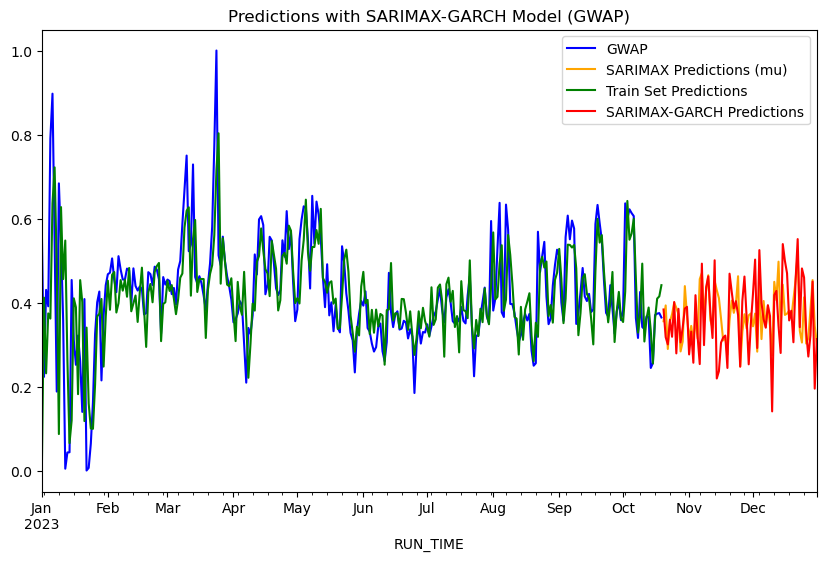

In [17]:
#Generate SARIMAX-GARCH predictions
%run GARCH.py

gwap_garch_predictions = garch_predict(
    'GWAP', 'ged', 'Garch', gwap_garch_fitted,
    GWAP_train,
    gwap_train_predict,
    gwap_test_predict
)

GWAP EGARCH

In [18]:
#Choosing order specification based on lowest AIC/BIC
%run GARCH.py

evaluate_garch(
    gwap_resid_train, 
    vol="EGARCH", 
    p_orders=[0,1,3,4,8], 
    q_orders=[0,1,3,4,6,7,8,11], 
    distributions=["normal", "t", "ged"], 
    sort_by="AIC"
)

Error for EGARCH(0,1) with normal distribution: One of p or o must be strictly positive
Error for EGARCH(0,1) with t distribution: One of p or o must be strictly positive
Error for EGARCH(0,1) with ged distribution: One of p or o must be strictly positive
Error for EGARCH(0,3) with normal distribution: One of p or o must be strictly positive
Error for EGARCH(0,3) with t distribution: One of p or o must be strictly positive
Error for EGARCH(0,3) with ged distribution: One of p or o must be strictly positive
Error for EGARCH(0,4) with normal distribution: One of p or o must be strictly positive
Error for EGARCH(0,4) with t distribution: One of p or o must be strictly positive
Error for EGARCH(0,4) with ged distribution: One of p or o must be strictly positive
Error for EGARCH(0,6) with normal distribution: One of p or o must be strictly positive
Error for EGARCH(0,6) with t distribution: One of p or o must be strictly positive
Error for EGARCH(0,6) with ged distribution: One of p or o mu

/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.01167. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.01167. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled

Error for EGARCH(8,1) with normal distribution: Singular matrix


/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.01167. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.01167. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled

,p,q,Volatility Model,Distribution,AIC,BIC,LLF,ARCH Stat,ARCH p-value,alpha_1,alpha_pval_1,beta_1,beta_pval_1,beta_2,beta_3,beta_pval_2,beta_pval_3,beta_4,beta_pval_4,beta_5,beta_6,beta_pval_5,beta_pval_6,beta_7,beta_pval_7,beta_8,beta_pval_8,beta_9,beta_10,beta_11,beta_pval_9,beta_pval_10,beta_pval_11,alpha_2,alpha_3,alpha_pval_2,alpha_pval_3,alpha_4,alpha_pval_4,alpha_5,alpha_6,alpha_7,alpha_8,alpha_pval_5,alpha_pval_6,alpha_pval_7,alpha_pval_8
0,8,1,EGARCH,ged,-649.528812,-609.084520,335.764406,164.122939,4.559608e-30,0.385942,3.092299e-01,9.828687e-01,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.311982,-0.058938,5.681773e-01,8.648181e-01,0.183243,0.695204,-0.386565,0.236119,0.004570,-0.184891,1.733482e-01,7.811850e-01,0.986437,6.827796e-01
1,8,11,EGARCH,t,-647.623887,-570.412057,344.811944,164.122939,4.559608e-30,0.753291,3.294766e-15,1.539355e-13,1.000000e+00,1.970781e-01,1.891432e-13,3.009427e-12,1.000000e+00,1.673200e-13,1.000000,3.702632e-13,1.497499e-01,1.000000,2.482221e-03,1.937833e-12,1.000000e+00,6.437942e-13,1.0,3.710453e-04,1.052684e-03,0.646874,0.990668,0.961979,0.000000,0.006381,0.564299,9.460854e-01,1.429389e-89,0.864701,0.000000,0.416800,0.415794,0.338743,0.947714,7.363097e-04,3.649765e-28,0.000977,0.000000e+00
2,1,1,EGARCH,ged,-647.303579,-632.596563,327.651789,164.122939,4.559608e-30,0.218407,3.976046e-02,9.514765e-01,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,3,EGARCH,ged,-646.993811,-624.933288,329.496906,164.122939,4.559608e-30,0.425433,2.314050e-03,2.393291e-01,5.332579e-01,1.552808e-01,5.080066e-01,8.031100e-01,8.231501e-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3,1,EGARCH,ged,-646.838876,-624.778353,329.419438,164.122939,4.559608e-30,0.430506,2.613204e-03,9.603840e-01,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.271294,-0.026264,1.262438e-01,8.430132e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,8,11,EGARCH,ged,-646.062940,-568.851110,344.031470,164.122939,4.559608e-30,0.818805,3.186179e-03,3.415420e-10,1.000000e+00,2.658557e-01,4.044316e-03,5.591925e-73,9.860786e-01,5.283357e-16,1.000000,8.152651e-13,1.161888e-01,1.000000,6.564575e-01,5.457729e-10,1.000000e+00,2.868007e-11,1.0,1.015563e-03,1.388860e-03,0.611451,0.992237,0.970595,0.000000,0.074170,0.478597,6.324990e-01,1.291484e-01,0.889928,0.000000,0.397217,0.348369,0.281263,0.806225,3.806619e-01,2.929298e-01,0.015009,0.000000e+00
6,1,4,EGARCH,ged,-645.026680,-619.289403,329.513340,164.122939,4.559608e-30,0.440607,5.618708e-03,2.001711e-01,7.240149e-01,3.162644e-02,5.757957e-01,9.741822e-01,3.525669e-01,8.773319e-02,0.912470,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,4,1,EGARCH,ged,-644.916940,-619.179663,329.458470,164.122939,4.559608e-30,0.423994,6.998694e-03,9.620575e-01,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.262389,0.000623,1.567926e-01,9.965021e-01,-0.054704,0.843194,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,8,1,EGARCH,t,-644.649006,-604.204715,333.324503,164.122939,4.559608e-30,0.317846,1.308012e-03,9.858507e-01,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.271933,0.020463,1.083423e-01,9.149030e-01,0.140415,0.513473,-0.397546,0.235155,-0.006369,-0.174738,3.575786e-04,2.774274e-01,0.980286,1.092066e-01
9,4,1,EGARCH,normal,-644.622965,-622.562442,328.311482,164.122939,4.559608e-30,0.255615,3.141298e-28,9.824049e-01,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.220035,0.026240,2.470275e-22,5.225617e-01,-0.176625,0.000160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
#Fitting EGARCH model
%run GARCH.py

gwap_egarch_fitted = fit_garch('GWAP', 'EGARCH', 1, 1, 'ged', '2023-10-20', gwap_resid_complete)

                             Zero Mean - EGARCH Model Results                             
Dep. Variable:                gwap_resid_complete   R-squared:                       0.000
Mean Model:                             Zero Mean   Adj. R-squared:                  0.003
Vol Model:                                 EGARCH   Log-Likelihood:                327.652
Distribution:      Generalized Error Distribution   AIC:                          -647.304
Method:                        Maximum Likelihood   BIC:                          -632.597
                                                    No. Observations:                  292
Date:                            Sat, Mar 15 2025   Df Residuals:                      292
Time:                                    16:44:06   Df Model:                            0
                              Volatility Model                             
                 coef    std err          t      P>|t|     95.0% Conf. Int.
-----------------------------

/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.01167. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.




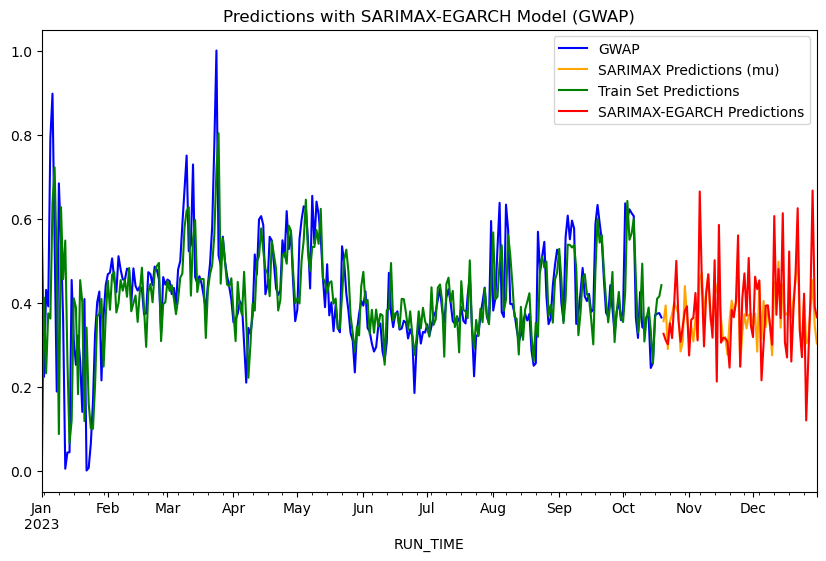

In [21]:
#Generate SARIMAX-EGARCH predictions
%run GARCH.py

gwap_egarch_predictions = garch_predict(
    'GWAP', 'ged', 'EGARCH', gwap_egarch_fitted,
    GWAP_train,
    gwap_train_predict,
    gwap_test_predict
)

LWAP Residual Analysis

In [22]:
#Generate residuals for LWAP

%run GARCH.py
lwap_resid_complete, lwap_resid_train = generate_resid(
    'LWAP',
    LWAP_train,
    LWAP_test,
    lwap_train_predict,
    lwap_test_predict,
    lwap_model_results
)

2023-01-01    0.568023
2023-01-02   -0.186076
2023-01-03    0.205447
2023-01-04    0.019464
2023-01-05    0.429926
2023-01-06    0.267401
2023-01-07   -0.166524
2023-01-08   -0.300820
2023-01-09    0.601702
2023-01-10   -0.091750
2023-01-11   -0.097397
2023-01-12   -0.534757
2023-01-13   -0.227563
2023-01-14   -0.024843
2023-01-15    0.334509
2023-01-16   -0.100938
2023-01-17   -0.137105
2023-01-18    0.135779
2023-01-19   -0.195997
2023-01-20   -0.260309
2023-01-21    0.287035
2023-01-22   -0.335717
2023-01-23   -0.157712
2023-01-24   -0.035734
2023-01-25    0.064090
2023-01-26    0.116573
2023-01-27    0.029290
2023-01-28    0.055647
2023-01-29   -0.193522
2023-01-30    0.119682
2023-01-31    0.074553
2023-02-01    0.016049
2023-02-02    0.090343
2023-02-03    0.038402
2023-02-04   -0.020352
2023-02-05    0.049842
2023-02-06    0.112970
2023-02-07    0.023995
2023-02-08    0.026131
2023-02-09    0.000058
2023-02-10    0.066308
2023-02-11   -0.004648
2023-02-12    0.016218
2023-02-13 

RUN_TIME
2023-01-01    0.568023
2023-01-02   -0.186076
2023-01-03    0.205447
2023-01-04    0.019464
2023-01-05    0.429926
2023-01-06    0.267401
2023-01-07   -0.166524
2023-01-08   -0.300820
2023-01-09    0.601702
2023-01-10   -0.091750
2023-01-11   -0.097397
2023-01-12   -0.534757
2023-01-13   -0.227563
2023-01-14   -0.024843
2023-01-15    0.334509
2023-01-16   -0.100938
2023-01-17   -0.137105
2023-01-18    0.135779
2023-01-19   -0.195997
2023-01-20   -0.260309
2023-01-21    0.287035
2023-01-22   -0.335717
2023-01-23   -0.157712
2023-01-24   -0.035734
2023-01-25    0.064090
2023-01-26    0.116573
2023-01-27    0.029290
2023-01-28    0.055647
2023-01-29   -0.193522
2023-01-30    0.119682
2023-01-31    0.074553
2023-02-01    0.016049
2023-02-02    0.090343
2023-02-03    0.038402
2023-02-04   -0.020352
2023-02-05    0.049842
2023-02-06    0.112970
2023-02-07    0.023995
2023-02-08    0.026131
2023-02-09    0.000058
2023-02-10    0.066308
2023-02-11   -0.004648
2023-02-12    0.016218
20

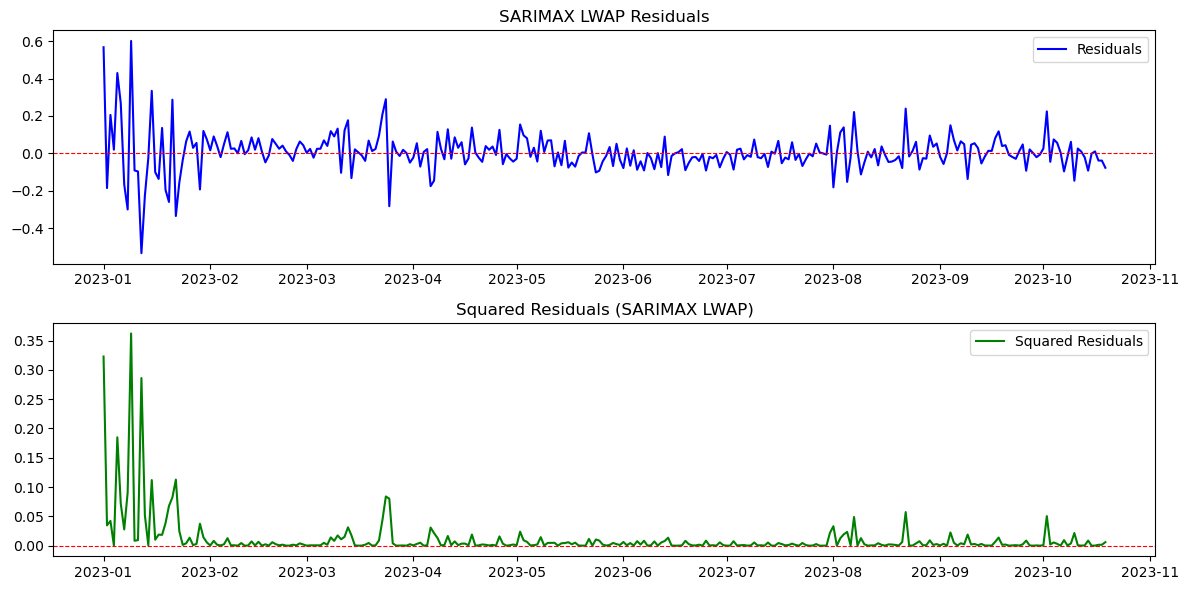

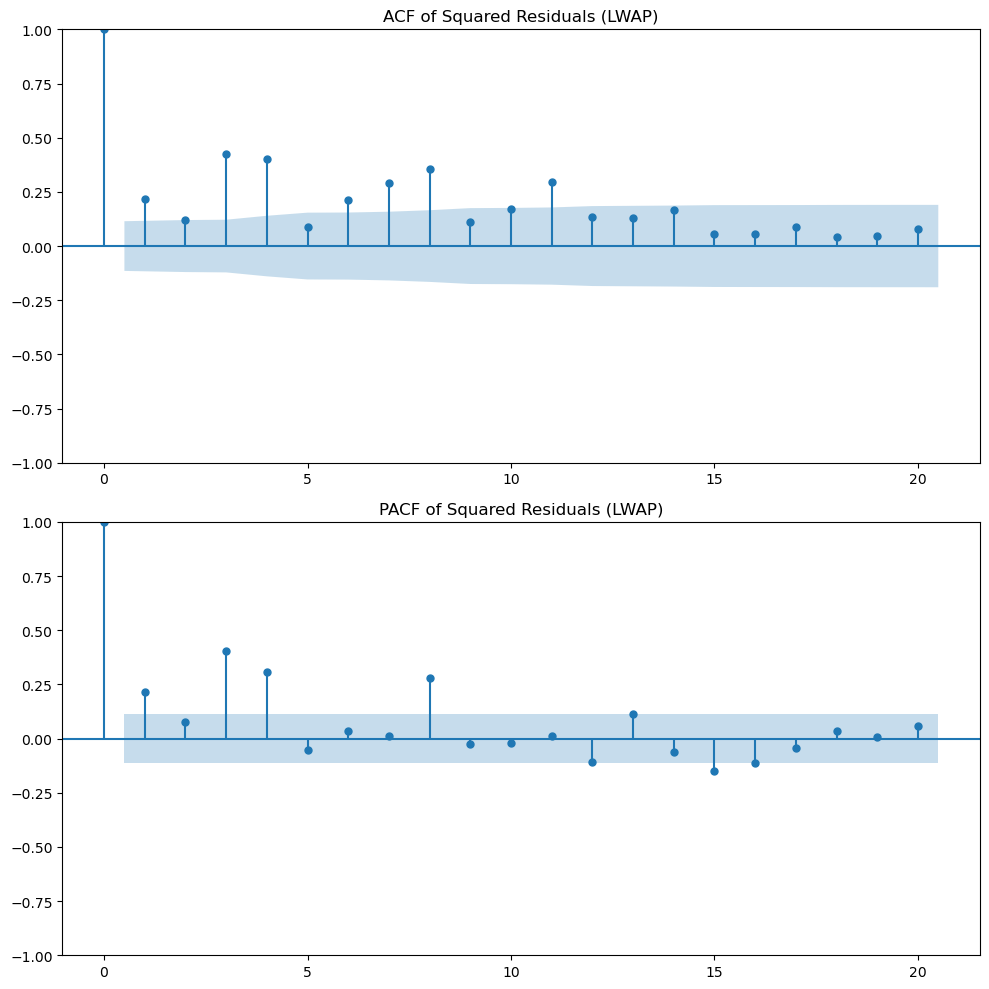

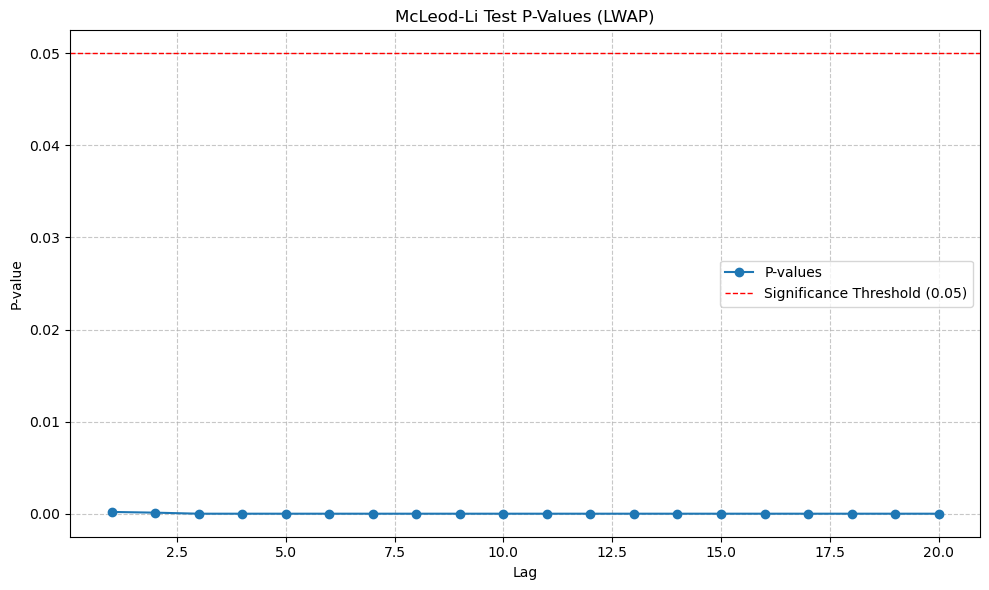

,Lag,PQ Test Stat,PQ p-value,LM Test Stat,LM p-value
0,1,13.906159,1.921677e-04,17.989187,2.221634e-05
1,2,18.158026,1.140341e-04,21.369585,2.289041e-05
2,3,71.781817,1.772769e-15,80.205221,2.773422e-17
3,4,119.731475,6.095557e-25,125.984866,2.811011e-26
4,5,121.999460,1.183435e-24,118.177110,7.634190e-24
5,6,135.330739,9.679237e-27,116.737665,7.887664e-23
6,7,160.902905,2.070962e-31,116.784173,3.577803e-22
7,8,198.784255,1.152459e-38,153.800704,3.157075e-29
8,9,202.462434,1.009073e-38,153.252161,1.868177e-28
9,10,211.431858,6.623580e-40,166.018431,1.849384e-30


In [23]:
#Conducting residual analysis
%run GARCH.py

garch_testing(lwap_resid_train, 'LWAP', max_lag=20)

LWAP GARCH

In [24]:
#Choosing order specification based on lowest AIC/BIC
%run GARCH.py

evaluate_garch(
    lwap_resid_train, 
    vol="GARCH", 
    p_orders=[0,1,3,4,8], 
    q_orders=[0,1,3,4,6,7,8,11], 
    distributions=["normal", "t", "ged"], 
    sort_by="AIC"
)

Error for GARCH(0,1) with normal distribution: One of p or o must be strictly positive
Error for GARCH(0,1) with t distribution: One of p or o must be strictly positive
Error for GARCH(0,1) with ged distribution: One of p or o must be strictly positive
Error for GARCH(0,3) with normal distribution: One of p or o must be strictly positive
Error for GARCH(0,3) with t distribution: One of p or o must be strictly positive
Error for GARCH(0,3) with ged distribution: One of p or o must be strictly positive
Error for GARCH(0,4) with normal distribution: One of p or o must be strictly positive
Error for GARCH(0,4) with t distribution: One of p or o must be strictly positive
Error for GARCH(0,4) with ged distribution: One of p or o must be strictly positive
Error for GARCH(0,6) with normal distribution: One of p or o must be strictly positive
Error for GARCH(0,6) with t distribution: One of p or o must be strictly positive
Error for GARCH(0,6) with ged distribution: One of p or o must be strict

/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.01164. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.01164. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled

,p,q,Volatility Model,Distribution,AIC,BIC,LLF,ARCH Stat,ARCH p-value,alpha_1,alpha_pval_1,beta_1,beta_pval_1,beta_2,beta_3,beta_pval_2,beta_pval_3,beta_4,beta_pval_4,beta_5,beta_6,beta_pval_5,beta_pval_6,beta_7,beta_pval_7,beta_8,beta_pval_8,beta_9,beta_10,beta_11,beta_pval_9,beta_pval_10,beta_pval_11,alpha_2,alpha_3,alpha_pval_2,alpha_pval_3,alpha_4,alpha_pval_4,alpha_5,alpha_6,alpha_7,alpha_8,alpha_pval_5,alpha_pval_6,alpha_pval_7,alpha_pval_8
0,1,3,GARCH,ged,-650.882463,-628.821940,331.441232,166.018431,1.849384e-30,0.237979,7.051765e-03,1.895817e-15,1.000000e+00,1.853097e-01,3.828314e-01,0.221581,0.000037,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,GARCH,ged,-650.386829,-635.679813,329.193414,166.018431,1.849384e-30,0.109774,4.481840e-02,7.988921e-01,1.715377e-33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,4,GARCH,ged,-648.882463,-623.145186,331.441231,166.018431,1.849384e-30,0.238009,1.304960e-02,0.000000e+00,1.000000e+00,1.852295e-01,3.828796e-01,0.484530,0.000026,2.068912e-17,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,3,GARCH,ged,-646.882463,-617.468433,331.441232,166.018431,1.849384e-30,0.237970,7.072589e-03,1.810439e-14,1.000000e+00,1.852483e-01,3.828923e-01,0.592310,0.000246,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.738008e-15,0.000000e+00,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,3,GARCH,t,-646.497627,-624.437104,329.248814,166.018431,1.849384e-30,0.249900,8.664592e-03,3.008821e-02,8.499037e-01,1.589999e-01,3.803724e-01,0.379895,0.000342,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1,6,GARCH,ged,-646.478367,-613.387583,332.239184,166.018431,1.849384e-30,0.266159,4.647180e-03,1.660483e-01,3.428966e-01,3.326380e-07,0.000000e+00,0.999999,1.000000,0.000000e+00,1.000000,0.000000e+00,3.419689e-01,1.000000,0.094318,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,3,1,GARCH,ged,-646.386829,-624.326306,329.193415,166.018431,1.849384e-30,0.109783,1.519590e-01,7.988709e-01,1.434547e-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.346710e-10,0.000000e+00,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1,1,GARCH,t,-646.279181,-631.572166,327.139591,166.018431,1.849384e-30,0.120001,4.830605e-02,7.936526e-01,1.958278e-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,4,0,GARCH,ged,-646.109648,-624.049125,329.054824,166.018431,1.849384e-30,0.303237,3.691605e-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.053959e-03,1.201089e-01,0.984067,0.036517,1.736018e-01,0.075036,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1,7,GARCH,ged,-645.105006,-608.337468,332.552503,166.018431,1.849384e-30,0.300399,2.045311e-03,1.208355e-02,9.526973e-01,0.000000e+00,0.000000e+00,1.000000,1.000000,0.000000e+00,1.000000,1.515997e-03,2.752225e-01,0.990323,0.217047,1.501599e-01,0.445919,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
#Fitting GARCH model
%run GARCH.py

lwap_garch_fitted = fit_garch('LWAP', 'Garch', 1, 3, 'ged', '2023-10-20', lwap_resid_complete)

/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.01164. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.




                             Zero Mean - GARCH Model Results                              
Dep. Variable:                lwap_resid_complete   R-squared:                       0.000
Mean Model:                             Zero Mean   Adj. R-squared:                  0.003
Vol Model:                                  GARCH   Log-Likelihood:                331.441
Distribution:      Generalized Error Distribution   AIC:                          -650.882
Method:                        Maximum Likelihood   BIC:                          -628.822
                                                    No. Observations:                  292
Date:                            Sat, Mar 15 2025   Df Residuals:                      292
Time:                                    16:44:28   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
---------------------------

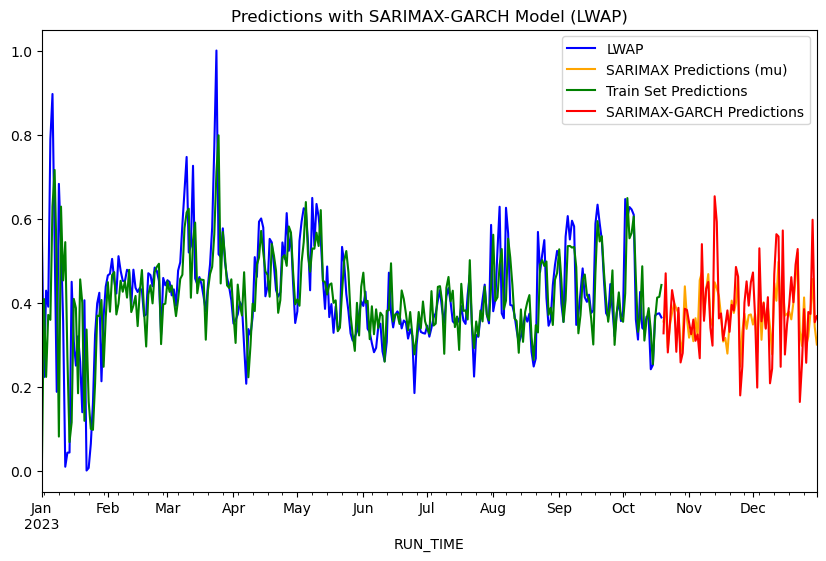

In [27]:
#Generate SARIMAX-GARCH predictions
%run GARCH.py

lwap_garch_predictions = garch_predict(
    'LWAP', 'ged', 'Garch', lwap_garch_fitted,
    LWAP_train,
    lwap_train_predict,
    lwap_test_predict
)

LWAP EGARCH

In [28]:
#Choosing order specification based on lowest AIC/BIC
%run GARCH.py

evaluate_garch(
    lwap_resid_train, 
    vol="EGARCH", 
    p_orders=[0,1,3,4,8], 
    q_orders=[0,1,3,4,6,7,8,11], 
    distributions=["normal", "t", "ged"], 
    sort_by="AIC"
)

Error for EGARCH(0,1) with normal distribution: One of p or o must be strictly positive
Error for EGARCH(0,1) with t distribution: One of p or o must be strictly positive
Error for EGARCH(0,1) with ged distribution: One of p or o must be strictly positive
Error for EGARCH(0,3) with normal distribution: One of p or o must be strictly positive
Error for EGARCH(0,3) with t distribution: One of p or o must be strictly positive
Error for EGARCH(0,3) with ged distribution: One of p or o must be strictly positive
Error for EGARCH(0,4) with normal distribution: One of p or o must be strictly positive
Error for EGARCH(0,4) with t distribution: One of p or o must be strictly positive
Error for EGARCH(0,4) with ged distribution: One of p or o must be strictly positive
Error for EGARCH(0,6) with normal distribution: One of p or o must be strictly positive
Error for EGARCH(0,6) with t distribution: One of p or o must be strictly positive
Error for EGARCH(0,6) with ged distribution: One of p or o mu

/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.01164. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.01164. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled

,p,q,Volatility Model,Distribution,AIC,BIC,LLF,ARCH Stat,ARCH p-value,alpha_1,alpha_pval_1,beta_1,beta_pval_1,beta_2,beta_3,beta_pval_2,beta_pval_3,beta_4,beta_pval_4,beta_5,beta_6,beta_pval_5,beta_pval_6,beta_7,beta_pval_7,beta_8,beta_pval_8,beta_9,beta_10,beta_11,beta_pval_9,beta_pval_10,beta_pval_11,alpha_2,alpha_3,alpha_pval_2,alpha_pval_3,alpha_4,alpha_pval_4,alpha_5,alpha_6,alpha_7,alpha_8,alpha_pval_5,alpha_pval_6,alpha_pval_7,alpha_pval_8
0,8,1,EGARCH,ged,-647.903106,-607.458814,334.951553,166.018431,1.849384e-30,0.322273,2.549861e-09,9.829841e-01,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.272047,-0.004643,0.009180,0.950575,0.167333,9.217143e-02,-0.377451,0.242900,0.013944,-0.227801,8.094273e-08,3.708103e-02,0.855476,4.622782e-05
1,1,1,EGARCH,ged,-644.738254,-630.031239,326.369127,166.018431,1.849384e-30,0.216581,2.942039e-02,9.508914e-01,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,3,EGARCH,ged,-644.497715,-622.437192,328.248857,166.018431,1.849384e-30,0.426655,2.189932e-03,2.598017e-01,5.223452e-01,7.103747e-02,5.701074e-01,9.411418e-01,3.224855e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1,EGARCH,ged,-643.938972,-621.878449,327.969486,166.018431,1.849384e-30,0.416881,2.539449e-03,9.599777e-01,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.262668,-0.024577,0.137273,0.854173,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8,1,EGARCH,t,-642.854012,-602.409721,332.427006,166.018431,1.849384e-30,0.324278,3.819468e-01,9.863522e-01,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.280195,-0.012498,0.853749,0.963617,0.195806,8.880072e-01,-0.383146,0.195854,0.060557,-0.235492,4.249345e-07,6.428473e-01,0.869115,4.689145e-01
5,4,1,EGARCH,normal,-642.817524,-620.757002,327.408762,166.018431,1.849384e-30,0.318359,1.665867e-08,9.825570e-01,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.299335,0.049573,0.000226,0.004612,-0.182637,3.046338e-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1,4,EGARCH,ged,-642.538578,-616.801301,328.269289,166.018431,1.849384e-30,0.438854,3.385360e-03,2.051072e-01,6.533263e-01,2.115321e-02,5.943788e-01,9.703934e-01,5.942989e-02,7.370261e-02,9.018653e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,4,1,EGARCH,ged,-641.969709,-616.232432,327.984854,166.018431,1.849384e-30,0.411913,7.340144e-03,9.611639e-01,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.257303,-0.007483,0.157533,0.957572,-0.034797,9.034462e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,3,3,EGARCH,ged,-640.915517,-611.501486,328.457758,166.018431,1.849384e-30,0.445993,4.512220e-03,0.000000e+00,1.000000e+00,4.464272e-01,4.574878e-01,4.460536e-01,3.682498e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.107029,-0.181389,0.836796,0.492712,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1,6,EGARCH,ged,-640.496796,-607.406012,329.248398,166.018431,1.849384e-30,0.481095,2.136818e-03,3.559894e-01,1.871698e-02,4.026759e-18,3.938064e-18,1.000000e+00,1.000000e+00,5.073362e-18,1.000000e+00,5.898226e-19,5.167256e-01,1.000000,2.228251e-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
#Fitting EGARCH model
%run GARCH.py

lwap_egarch_fitted = fit_garch('LWAP', 'EGARCH', 1, 1, 'ged', '2023-10-20', lwap_resid_complete)

                             Zero Mean - EGARCH Model Results                             
Dep. Variable:                lwap_resid_complete   R-squared:                       0.000
Mean Model:                             Zero Mean   Adj. R-squared:                  0.003
Vol Model:                                 EGARCH   Log-Likelihood:                326.369
Distribution:      Generalized Error Distribution   AIC:                          -644.738
Method:                        Maximum Likelihood   BIC:                          -630.031
                                                    No. Observations:                  292
Date:                            Sat, Mar 15 2025   Df Residuals:                      292
Time:                                    16:44:48   Df Model:                            0
                              Volatility Model                             
                 coef    std err          t      P>|t|     95.0% Conf. Int.
-----------------------------

/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.01164. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.




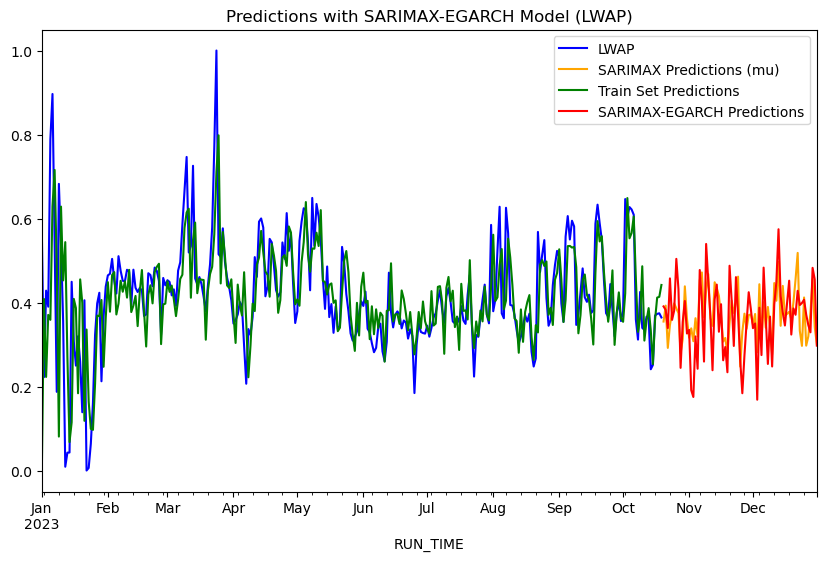

In [31]:
#Generate SARIMAX-GARCH predictions
%run GARCH.py

lwap_egarch_predictions = garch_predict(
    'LWAP', 'normal', 'EGARCH', lwap_egarch_fitted,
    LWAP_train,
    lwap_train_predict,
    lwap_test_predict
)

Applying inverse transformations

In [32]:
def prep_predictions(gwap_predictions, lwap_predictions):
    gwap_predictions_df = gwap_predictions.to_frame(name='GWAP')
    lwap_predictions_df = lwap_predictions.to_frame(name='LWAP')

    %run transformscript.py

    inverse_gwap_predictions = inverse_transform_data(gwap_predictions_df, 'SARIMAX', 'LUZ', 'GWAP')
    inverse_lwap_predictions = inverse_transform_data(lwap_predictions_df, 'SARIMAX', 'LUZ', 'LWAP')

    return inverse_gwap_predictions, inverse_lwap_predictions

In [33]:
#Preparing the predictions of the various time series models
inverse_gwap_sarimax_predictions, inverse_lwap_sarimax_predictions = prep_predictions(gwap_test_predict, lwap_test_predict)
inverse_gwap_garch_predictions, inverse_lwap_garch_predictions = prep_predictions(gwap_garch_predictions, lwap_garch_predictions)
inverse_gwap_egarch_predictions, inverse_lwap_egarch_predictions = prep_predictions(gwap_egarch_predictions, lwap_egarch_predictions)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning:

Trying to unpickle estimator PowerTransformer from version 1.6.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning:

Trying to unpickle estimator MinMaxScaler from version 1.6.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning:

Trying to unpickle estimator Pipeline from version 1.6.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at

Mean Absolute Error (MAE) on Test Set for GWAP: 825.5022382226208
Root Mean Squared Error (RMSE) on Test Set for GWAP: 1040.2795091585679
Mean Absolute Percentage Error (MAPE) on Test Set for GWAP: 26.15824976336786


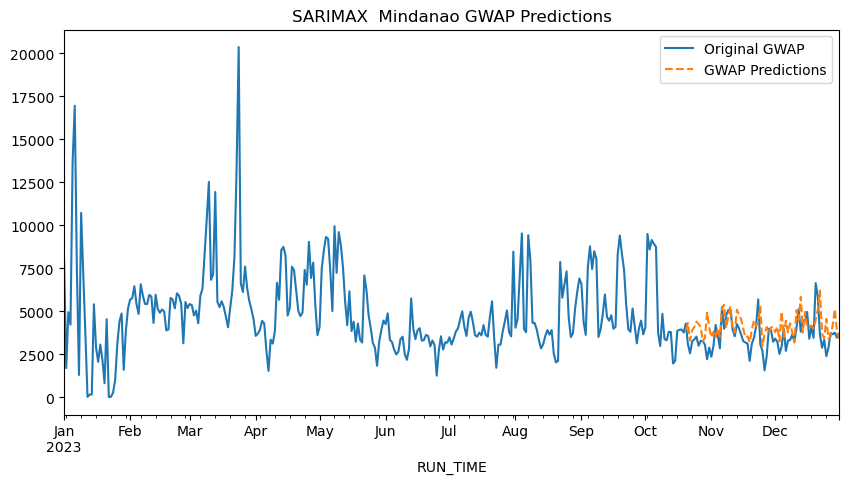

Mean Absolute Error (MAE) on Test Set for LWAP: 940.6876922193885
Root Mean Squared Error (RMSE) on Test Set for LWAP: 1183.571849172585
Mean Absolute Percentage Error (MAPE) on Test Set for LWAP: 28.610113311867835


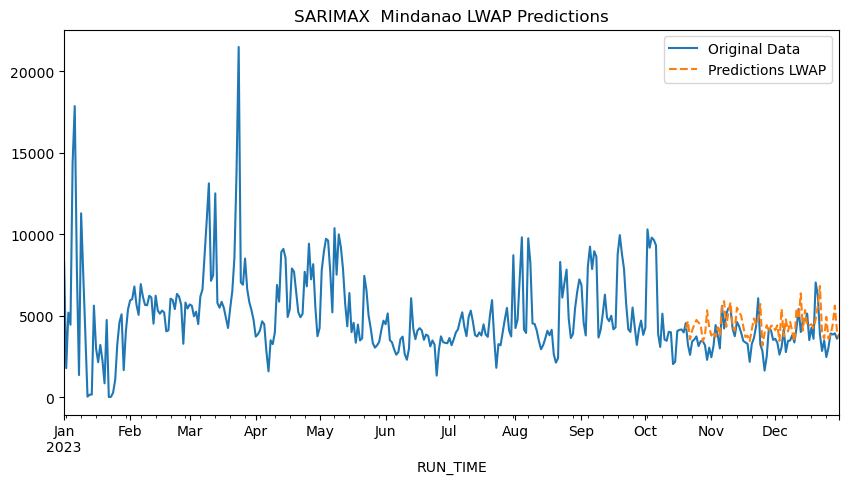

In [34]:
#Assessing SARIMAX model

%run SARIMAX.py
gwap_mae_test, gwap_rmse_test, mape_test_gwap, mape_test_lwap, lwap_rmse_test, lwap_rmse_test = evaluate_models(complete_min_gwap, complete_min_lwap, GWAP_test_original = untransformed_GWAP_test, GWAP_predictions_inverse= inverse_gwap_sarimax_predictions, LWAP_test_original=untransformed_LWAP_test, LWAP_predictions_inverse=inverse_lwap_sarimax_predictions, Region = 'Mindanao', Volatility = '')

Mean Absolute Error (MAE) on Test Set for GWAP: 1034.7401639802931
Root Mean Squared Error (RMSE) on Test Set for GWAP: 1346.0461339210792
Mean Absolute Percentage Error (MAPE) on Test Set for GWAP: 31.994861860133128


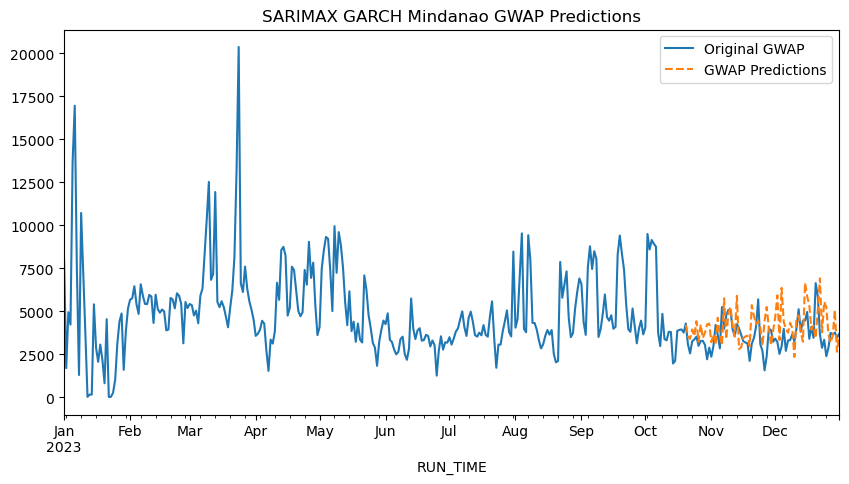

Mean Absolute Error (MAE) on Test Set for LWAP: 1332.608335525257
Root Mean Squared Error (RMSE) on Test Set for LWAP: 1848.7508190634883
Mean Absolute Percentage Error (MAPE) on Test Set for LWAP: 37.519061866653345


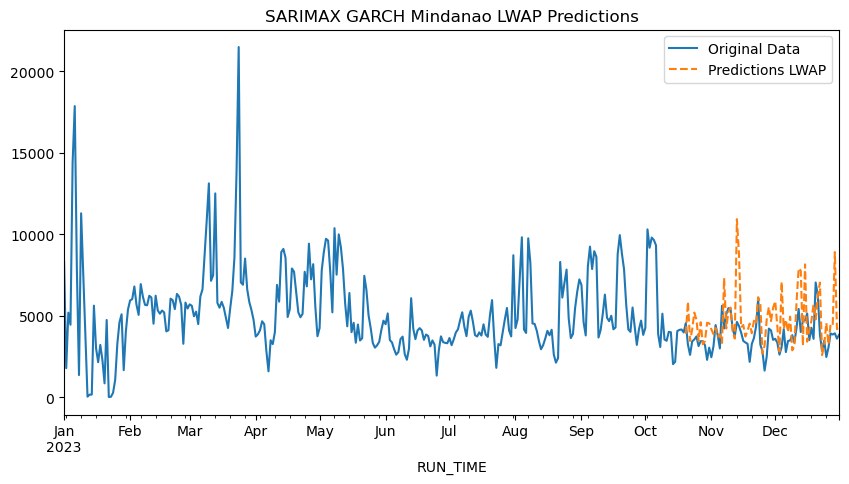

In [35]:
#Assessing SARIMAX-GARCH model

%run SARIMAX.py
gwap_mae_test, gwap_rmse_test, mape_test_gwap, mape_test_lwap, lwap_rmse_test, lwap_rmse_test = evaluate_models(complete_min_gwap, complete_min_lwap, GWAP_test_original = untransformed_GWAP_test, GWAP_predictions_inverse= inverse_gwap_garch_predictions, LWAP_test_original=untransformed_LWAP_test, LWAP_predictions_inverse=inverse_lwap_garch_predictions, Region = 'Mindanao', Volatility = 'GARCH')

Mean Absolute Error (MAE) on Test Set for GWAP: 1317.6910994118848
Root Mean Squared Error (RMSE) on Test Set for GWAP: 1902.2380538573716
Mean Absolute Percentage Error (MAPE) on Test Set for GWAP: 39.221822438856165


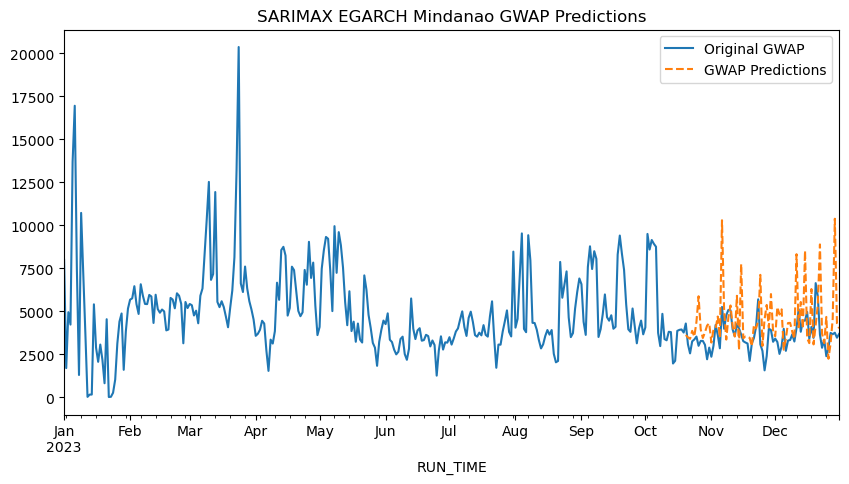

Mean Absolute Error (MAE) on Test Set for LWAP: 1035.8377664176842
Root Mean Squared Error (RMSE) on Test Set for LWAP: 1371.7025384237759
Mean Absolute Percentage Error (MAPE) on Test Set for LWAP: 30.23762723652374


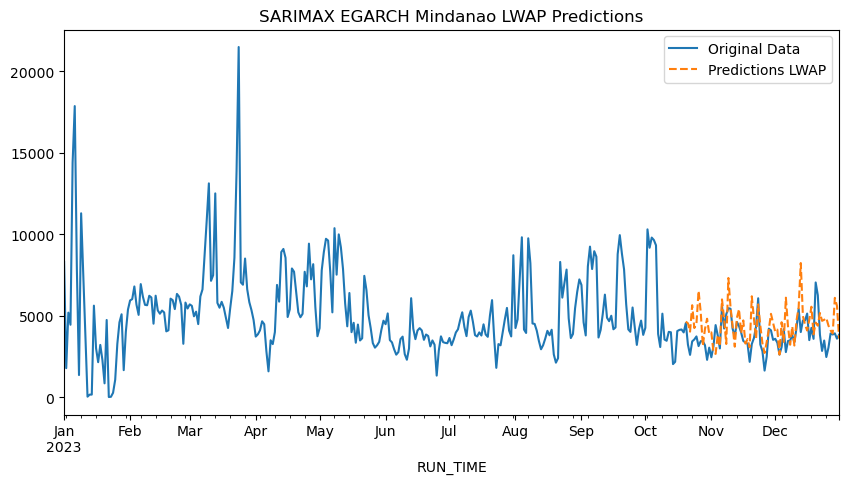

In [36]:
#Assessing SARIMAX-EGARCH model

%run SARIMAX.py
gwap_mae_test, gwap_rmse_test, mape_test_gwap, mape_test_lwap, lwap_rmse_test, lwap_rmse_test = evaluate_models(complete_min_gwap, complete_min_lwap, GWAP_test_original = untransformed_GWAP_test, GWAP_predictions_inverse= inverse_gwap_egarch_predictions, LWAP_test_original=untransformed_LWAP_test, LWAP_predictions_inverse=inverse_lwap_egarch_predictions, Region = 'Mindanao', Volatility = 'EGARCH')